# 04 Markov Regime-Switching Volatility & Correlation

**In this notebook** Estimate a 2-state (calm/volatile) Markov regime-switching model
on the pair's *training* returns, then answer two questions at the traded
strike $K_{\text{ATM}}$:

1. **Pricing:** how different is the spread-option price under regime
   switching from the constant-parameter price? (model risk)
2. **Hedging:** does a hedger who *detects* the current regime from trailing
   realized vol beat a hedger who uses constant mixed parameters?


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm

TICKERS = ("MO", "PM")
DATA_START, DATA_END = "2021-01-01", "2026-07-01"
TRAIN_END = "2024-07-01"
TRADING_DAYS, r_f = 252, 0.04

BETA, ALPHA = 0.735372, 0.302487
KAPPA, THETA = 6.935348, 0.004386
SIGMA_X, SIGMA_STAT = 0.176370, 0.047356
HALF_LIFE_DAYS = 25.1859
MAX_HOLD, T_OPT = 50, 0.198413
Z_ENTRY, Z_EXIT = 2.0, 0.0

SIGMA1, SIGMA2, RHO = 0.209149, 0.194565, 0.560769
S1_0, S2_0 = 40.0410, 94.0219
H_RATIO = 0.313172               # = BETA * S1_0 / S2_0; weight on leg 2

H = H_RATIO
A0 = S1_0
B0 = H * S2_0
K_ATM = A0 - B0

T = T_OPT
n_steps = MAX_HOLD
dt = T / n_steps

SPREAD_SIGMA = np.sqrt(A0**2 * SIGMA1**2 + B0**2 * SIGMA2**2
                       - 2 * RHO * A0 * B0 * SIGMA1 * SIGMA2) * np.sqrt(T)

rng = np.random.default_rng(4)
plt.rcParams["figure.figsize"] = (10, 5)
print(f"traded strike K_ATM = {K_ATM:.2f}, T = {T:.3f}y, {n_steps} daily steps")


traded strike K_ATM = 10.60, T = 0.198y, 50 daily steps


# 5. Markov regime-switching volatility & correlation

## 5.1 The model

Let $Y_t \in \{0, 1\}$ (calm / volatile) be a 2-state Markov chain with transition matrix
$$P = \begin{pmatrix} p_{00} & 1-p_{00} \\ 1-p_{11} & p_{11} \end{pmatrix},$$
and let the GBM parameters depend on the regime: $(\sigma_1, \sigma_2, \rho) = (\sigma_1^{(Y_t)}, \sigma_2^{(Y_t)}, \rho^{(Y_t)})$. In stress regimes, vols rise *and* the pair's correlation moves, which is the exact failure mode of pairs trades.

## 5.2 Estimation (training window only)

A transparent two-step approach:

1. Compute 21-day realized vol of leg 1; label regime 1 (volatile) when it
   exceeds its 75th percentile.
2. Estimate $\hat p_{ij} = n_{ij} / \sum_k n_{ik}$ by counting observed
   transitions; estimate $(\sigma_1, \sigma_2, \rho)$ within each regime from
   the labeled returns.

Stationary distribution $\pi P = \pi$:
$\pi_1 = \frac{1 - p_{00}}{2 - p_{00} - p_{11}}$.

In [3]:
# From notebooks 02–03
def _margrabe_d1_d2(S1, S2, sigma1, sigma2, rho, T):
    sig_hat = np.sqrt(sigma1**2 - 2*rho*sigma1*sigma2 + sigma2**2)
    sqT = sig_hat * np.sqrt(T)
    d1 = (np.log(S1 / S2) + 0.5 * sig_hat**2 * T) / sqT
    return d1, d1 - sqT


def margrabe_price(S1, S2, sigma1, sigma2, rho, T):
    d1, d2 = _margrabe_d1_d2(S1, S2, sigma1, sigma2, rho, T)
    return S1 * norm.cdf(d1) - S2 * norm.cdf(d2)


def simulate_correlated_gbm(S1_0, S2_0, sigma1, sigma2, rho, r, T,
                            n_steps, n_paths, rng):
    dt = T / n_steps
    eps = rng.standard_normal((n_paths, n_steps, 2))
    z1 = eps[:, :, 0]
    z2 = rho * eps[:, :, 0] + np.sqrt(1.0 - rho**2) * eps[:, :, 1]

    def build(S0, sigma, z):
        log_inc = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z
        logS = np.concatenate([np.full((n_paths, 1), np.log(S0)),
                               np.log(S0) + np.cumsum(log_inc, axis=1)], axis=1)
        return np.exp(logS)

    return build(S1_0, sigma1, z1), build(S2_0, sigma2, z2)


def _cv_adjust(P, C, EC):
    cov = np.cov(P, C, ddof=1)
    var_C = cov[1, 1]
    if var_C < 1e-14:
        return P, 0.0, 0.0
    b_star = cov[0, 1] / var_C
    corr = cov[0, 1] / np.sqrt(cov[0, 0] * var_C) if cov[0, 0] > 0 else 0.0
    return P - b_star * (C - EC), b_star, corr


def mc_spread_option_margrabe_cv(A_T, B_T, K, r, T, margrabe_V):
    P = np.maximum(A_T - B_T - K, 0.0)
    C = np.maximum(A_T - B_T, 0.0)
    P_adj, b_star, corr = _cv_adjust(P, C, np.exp(r * T) * margrabe_V)
    disc = np.exp(-r * T)
    return (disc * P_adj.mean(),
            disc * P_adj.std(ddof=1) / np.sqrt(len(P_adj)), b_star, corr)


def _terminal_factors(sigma1, sigma2, rho, r, tau, M, rng):
    eps = rng.standard_normal((M, 2))
    z1 = eps[:, 0]
    z2 = rho * eps[:, 0] + np.sqrt(1 - rho**2) * eps[:, 1]
    fA = np.exp((r - 0.5 * sigma1**2) * tau + sigma1 * np.sqrt(tau) * z1)
    fB = np.exp((r - 0.5 * sigma2**2) * tau + sigma2 * np.sqrt(tau) * z2)
    return fA, fB


def mc_deltas_fd_batch(A_vec, B_vec, tau, K, params, h_rel=0.01,
                       M=4_000, seed=0, chunk=4_000):
    p = params
    rng = np.random.default_rng(seed)
    fA, fB = _terminal_factors(p["sigma1"], p["sigma2"], p["rho"], p["r"],
                               tau, M, rng)
    disc = np.exp(-p["r"] * tau)
    dA = np.empty_like(A_vec)
    dB = np.empty_like(B_vec)

    for lo in range(0, len(A_vec), chunk):
        sl = slice(lo, lo + chunk)
        a, b = A_vec[sl, None], B_vec[sl, None]
        ha, hb = h_rel * a, h_rel * b

        def price(x, y):
            return disc * np.maximum(x * fA - y * fB - K, 0.0).mean(axis=1)

        dA[sl] = (price(a + ha, b) - price(a - ha, b)) / (2 * ha[:, 0])
        dB[sl] = (price(a, b + hb) - price(a, b - hb)) / (2 * hb[:, 0])
    return dA, dB

In [4]:
def label_regimes(returns: pd.DataFrame, window=21, q=0.75) -> pd.Series:
    """0/1 regime labels from rolling realized vol of leg 1."""
    rv = returns.iloc[:, 0].rolling(window).std() * np.sqrt(TRADING_DAYS)
    rv = rv.dropna()
    labels = (rv > rv.quantile(q)).astype(int)
    labels.name = "regime"
    return labels


def estimate_regime_params(returns: pd.DataFrame, labels: pd.Series):
    """Transition matrix, per-regime (sigma1, sigma2, rho), stationary pi."""
    ret = returns.loc[labels.index]
    y = labels.values

    P = np.zeros((2, 2))
    for i in range(2):
        for j in range(2):
            P[i, j] = np.sum((y[:-1] == i) & (y[1:] == j))
    P = P / P.sum(axis=1, keepdims=True)

    sigma1, sigma2, rho = np.zeros(2), np.zeros(2), np.zeros(2)
    counts = np.zeros(2, dtype=int)
    for k in range(2):
        rk = ret[y == k]
        counts[k] = len(rk)
        sigma1[k] = rk.iloc[:, 0].std(ddof=1) * np.sqrt(TRADING_DAYS)
        sigma2[k] = rk.iloc[:, 1].std(ddof=1) * np.sqrt(TRADING_DAYS)
        rho[k] = rk.iloc[:, 0].corr(rk.iloc[:, 1])

    pi1 = (1 - P[0, 0]) / (2 - P[0, 0] - P[1, 1])
    return dict(P=P, sigma1=sigma1, sigma2=sigma2, rho=rho,
                pi=np.array([1 - pi1, pi1]), counts=counts)


def simulate_regime_switching_gbm(A0, B0, regime_params, r, T, n_steps,
                                  n_paths, rng, start_regime=None):
    """Correlated GBM with Markov-modulated (sigma1, sigma2, rho). i.i.d. paths.
    Returns (A, B, regimes); regimes has shape (n_paths, n_steps)."""
    rp = regime_params
    dt = T / n_steps

    if start_regime is None:
        y = (rng.random(n_paths) < rp["pi"][1]).astype(int)
    else:
        y = np.full(n_paths, start_regime, dtype=int)
    regimes = np.empty((n_paths, n_steps), dtype=int)
    stay = np.array([rp["P"][0, 0], rp["P"][1, 1]])
    for t in range(n_steps):
        regimes[:, t] = y
        y = np.where(rng.random(n_paths) < stay[y], y, 1 - y)

    eps = rng.standard_normal((n_paths, n_steps, 2))
    s1, s2, rh = (rp["sigma1"][regimes], rp["sigma2"][regimes],
                  rp["rho"][regimes])
    z1 = eps[:, :, 0]
    z2 = rh * eps[:, :, 0] + np.sqrt(1.0 - rh**2) * eps[:, :, 1]

    def build(S0, s, z):
        inc = (r - 0.5 * s**2) * dt + s * np.sqrt(dt) * z
        return np.exp(np.concatenate(
            [np.full((n_paths, 1), np.log(S0)),
             np.log(S0) + np.cumsum(inc, axis=1)], axis=1))
    return build(A0, s1, z1), build(B0, s2, z2), regimes


def margrabe_price_sighat(S1, S2, sig_hat, T):
    """Margrabe price parametrized directly by effective vol."""
    sqT = sig_hat * np.sqrt(T)
    d1 = (np.log(S1 / S2) + 0.5 * sig_hat**2 * T) / sqT
    return S1 * norm.cdf(d1) - S2 * norm.cdf(d1 - sqT)


def margrabe_cv_mean_regime(A0, B0, regime_params, T, n_steps,
                            n_regime_paths, rng):
    """K=0 price under regime switching: conditional on a regime path the
    ratio A/B is lognormal with the path's integrated effective variance, so
    the price is the average of Margrabe prices at path-integrated vols.
    Supplies the exact E[C] for the Margrabe control variate on RS paths."""
    rp = regime_params
    sighat_k = np.sqrt(rp["sigma1"]**2 - 2*rp["rho"]*rp["sigma1"]*rp["sigma2"]
                       + rp["sigma2"]**2)
    y = (rng.random(n_regime_paths) < rp["pi"][1]).astype(int)
    stay = np.array([rp["P"][0, 0], rp["P"][1, 1]])
    var_sum = np.zeros(n_regime_paths)
    for t in range(n_steps):
        var_sum += sighat_k[y]**2
        y = np.where(rng.random(n_regime_paths) < stay[y], y, 1 - y)
    bar_sig = np.sqrt(var_sum / n_steps)
    vals = margrabe_price_sighat(A0, B0, bar_sig, T)
    return vals.mean(), vals.std(ddof=1) / np.sqrt(n_regime_paths)


def expected_param_grids(regime_params, n_steps, T):
    """Regime-conditional EXPECTED parameters over the remaining life.

    For current regime y at step k with n = n_steps - k remaining steps,
    returns effective constants (s1_eff, s2_eff, rho_eff)[y, k] such that a
    constant-parameter model with these values matches the expected
    integrated variances/covariance E[int sigma_i^2], E[int rho s1 s2 | Y_k=y]
    of the regime-switching model. These feed the FD delta engine."""
    rp = regime_params
    v1 = rp["sigma1"]**2
    v2 = rp["sigma2"]**2
    cv = rp["rho"] * rp["sigma1"] * rp["sigma2"]

    E1 = np.empty((2, n_steps))
    E2 = np.empty((2, n_steps))
    Ec = np.empty((2, n_steps))
    dist = np.eye(2)
    for j in range(n_steps):                 # E[f(Y_{k+j}) | Y_k = y]
        E1[:, j] = dist @ v1
        E2[:, j] = dist @ v2
        Ec[:, j] = dist @ cv
        dist = dist @ rp["P"]
    c1, c2, cc = (np.cumsum(E1, axis=1), np.cumsum(E2, axis=1),
                  np.cumsum(Ec, axis=1))

    s1_eff = np.empty((2, n_steps))
    s2_eff = np.empty((2, n_steps))
    rho_eff = np.empty((2, n_steps))
    for k in range(n_steps):
        n = n_steps - k
        s1_eff[:, k] = np.sqrt(c1[:, n - 1] / n)
        s2_eff[:, k] = np.sqrt(c2[:, n - 1] / n)
        rho_eff[:, k] = (cc[:, n - 1] / n) / (s1_eff[:, k] * s2_eff[:, k])
    return s1_eff, s2_eff, rho_eff


def detect_regimes_from_paths(A_paths, dt, regime_params, window=21):
    """Regime detected from trailing realized vol of leg A, per path/step.
    Before the window fills, defaults to calm (0)."""
    logret = np.diff(np.log(A_paths), axis=1)
    n_paths, n_steps = logret.shape
    thr = 0.5 * (regime_params["sigma1"][0] + regime_params["sigma1"][1])
    detected = np.zeros((n_paths, n_steps), dtype=int)
    c1 = np.cumsum(logret, axis=1)
    c2 = np.cumsum(logret**2, axis=1)
    for t in range(window, n_steps):
        s = c1[:, t] - c1[:, t - window]
        ss = c2[:, t] - c2[:, t - window]
        var = (ss - s**2 / window) / (window - 1)
        detected[:, t] = (np.sqrt(np.maximum(var, 0) / dt) > thr).astype(int)
    return detected


def simulate_delta_hedge_rs(A_paths, B_paths, K, r, T, V0,
                            rebalance_every, delta_fn):
    """Discrete hedge of a SHORT option; delta_fn(k, tau) -> (dA, dB)."""
    n_paths, n_cols = A_paths.shape
    n_steps = n_cols - 1
    dt = T / n_steps
    payoff = np.maximum(A_paths[:, -1] - B_paths[:, -1] - K, 0.0)
    pnl = V0 * np.exp(r * T) - payoff
    if rebalance_every is None:
        return pnl
    gains = np.zeros(n_paths)
    for k in range(0, n_steps, rebalance_every):
        k_next = min(k + rebalance_every, n_steps)
        tau = T - k * dt
        dA, dB = delta_fn(k, tau)
        grow = np.exp(r * (k_next - k) * dt)
        inc = (dA * (A_paths[:, k_next] - A_paths[:, k] * grow) +
               dB * (B_paths[:, k_next] - B_paths[:, k] * grow))
        gains += inc * np.exp(r * (T - k_next * dt))
    return pnl + gains


In [5]:
# Estimate the regime model on TRAINING data (same window as notebook 01)
prices_train = (yf.download(list(TICKERS), start=DATA_START, end=TRAIN_END,
                            auto_adjust=True, progress=False)["Close"]
                [list(TICKERS)].dropna(how="any"))
logret_train = np.log(prices_train).diff().dropna()

labels = label_regimes(logret_train, window=21, q=0.75)
rp = estimate_regime_params(logret_train, labels)

regime_table = pd.DataFrame(
    {"calm (0)": [rp["sigma1"][0], rp["sigma2"][0], rp["rho"][0],
                  rp["P"][0, 0], rp["pi"][0], rp["counts"][0]],
     "volatile (1)": [rp["sigma1"][1], rp["sigma2"][1], rp["rho"][1],
                      rp["P"][1, 1], rp["pi"][1], rp["counts"][1]]},
    index=[f"sigma_{TICKERS[0]}", f"sigma_{TICKERS[1]}", "rho",
           "P(stay)", "pi", "n_days"]).round(4)
print(regime_table)

dur_vol = 1.0 / (1.0 - rp["P"][1, 1])
print(f"\nexpected volatile-regime duration: {dur_vol:.1f} days "
      f"vs detection window: 21 days")

          calm (0)  volatile (1)
sigma_MO    0.1578        0.3160
sigma_PM    0.1720        0.2516
rho         0.6034        0.5249
P(stay)     0.9782        0.9346
pi          0.7497        0.2503
n_days    642.0000      214.0000

expected volatile-regime duration: 15.3 days vs detection window: 21 days


## 5.3 Pricing under regime switching (model risk)

Simulate the market with Markov-modulated $(\sigma_1, \sigma_2, \rho)$ and
price the spread option on those paths with the Margrabe control variate.
Conditional on a regime path, $A/B$ is lognormal with the path-integrated
effective variance, so the exact $K = 0$ price under regime switching is the
*average of Margrabe prices at path-integrated vols*
(`margrabe_cv_mean_regime`). this supplies the control's mean $\mathbb E[C]$
on RS paths, keeping the estimator unbiased. The constant-parameter benchmark
uses the training-window $(\sigma_1, \sigma_2, \rho)$ from notebook 01 on
plain GBM paths. Regime switching creates a *mixture* of integrated
variances; by Jensen-type convexity effects the option price differs from
the price at the average variance, and the sign/size of the gap is an
empirical question answered below, strike by strike.


    K  price_RS  se_RS  price_BS  se_BS    diff  diff_pct
 0.00   10.5967 0.0000   10.5961 0.0000  0.0006    0.0060
 7.47    3.4184 0.0010    3.4143 0.0009  0.0041    0.1205
10.60    1.2565 0.0016    1.2830 0.0015 -0.0265   -2.0656
13.72    0.2982 0.0012    0.2992 0.0011 -0.0010   -0.3409
16.84    0.0564 0.0006    0.0426 0.0005  0.0138   32.3172


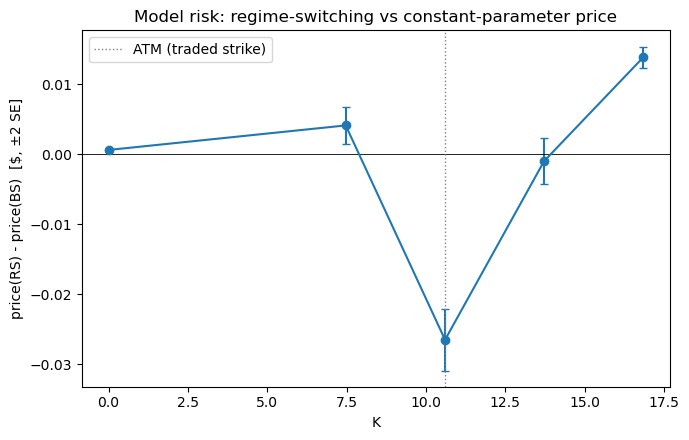

In [6]:
K_GRID = [0.0,
          float(round(K_ATM - SPREAD_SIGMA, 2)),
          float(round(K_ATM, 2)),
          float(round(K_ATM + SPREAD_SIGMA, 2)),
          float(round(K_ATM + 2 * SPREAD_SIGMA, 2))]

N_PRICE = 400_000

# regime-switching paths + exact K=0 mean for the CV
Ar, Br, _ = simulate_regime_switching_gbm(A0, B0, rp, r_f, T, n_steps,
                                          N_PRICE, rng)
V0_rs_K0, _ = margrabe_cv_mean_regime(A0, B0, rp, T, n_steps,
                                      500_000, np.random.default_rng(22))

# constant-parameter paths + Margrabe closed form for the CV
Ac, Bc = simulate_correlated_gbm(A0, B0, SIGMA1, SIGMA2, RHO, r_f, T,
                                 1, N_PRICE, np.random.default_rng(23))
V0_bs_K0 = margrabe_price(A0, B0, SIGMA1, SIGMA2, RHO, T)

rows = []
for K in K_GRID:
    pr_rs, se_rs, _, _ = mc_spread_option_margrabe_cv(
        Ar[:, -1], Br[:, -1], K, r_f, T, V0_rs_K0)
    pr_bs, se_bs, _, _ = mc_spread_option_margrabe_cv(
        Ac[:, -1], Bc[:, -1], K, r_f, T, V0_bs_K0)
    rows.append((K, pr_rs, se_rs, pr_bs, se_bs, pr_rs - pr_bs,
                 100 * (pr_rs - pr_bs) / pr_bs if pr_bs > 0 else np.nan))
price_cmp = pd.DataFrame(rows, columns=["K", "price_RS", "se_RS",
                                        "price_BS", "se_BS", "diff",
                                        "diff_pct"]).round(4)
print(price_cmp.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(price_cmp["K"], price_cmp["diff"],
            yerr=2 * np.hypot(price_cmp["se_RS"], price_cmp["se_BS"]),
            fmt="o-", capsize=3)
ax.axhline(0, color="k", lw=0.6)
ax.axvline(K_ATM, color="grey", ls=":", lw=1, label="ATM (traded strike)")
ax.set_xlabel("K")
ax.set_ylabel("price(RS) - price(BS)  [$, ±2 SE]")
ax.set_title("Model risk: regime-switching vs constant-parameter price")
ax.legend()
plt.tight_layout()
plt.show()


## 5.4 Hedging race: naive constant-parameter vs regime-aware

Simulate the *market* under regime switching and hedge a **short
$K_{\text{ATM}}$ option** weekly with two hedgers that share the same FD
delta engine and differ only in parameters:

- **(a) Naive BS hedger:** constant parameters obtained by stationary
  variance/covariance mixing,
  $\bar\sigma_i^2 = \sum_y \pi_y \sigma_i^{(y)2}$,
  $\bar\rho = \sum_y \pi_y \rho^{(y)}\sigma_1^{(y)}\sigma_2^{(y)} / (\bar\sigma_1\bar\sigma_2)$
  — the constant model that matches the unconditional second moments.
- **(b) Regime-aware hedger:** detects the regime from 21-day trailing
  realized vol of leg $A$, then uses the regime-conditional **expected
  parameters over the remaining life** (`expected_param_grids`), which
  account for future switching rather than freezing the current regime.

Both are charged the same premium, the *true* RS model value of the option, 
so both P&L distributions are centered near zero and differ only in shape.
We report overall risk and risk on the subset of paths that ever visit the
volatile regime, where regime information should matter most.

**Detection-lag hypothesis:** if the volatile regime's expected duration is
shorter than the 21-day detection window (see Sect. 5.2 printout), the detector
mostly recognizes the regime after it has ended, and (b) should struggle to
beat (a).


RS premium V0(K_ATM) = 1.2585 (SE 0.0016)
naive constants: sigma1 = 0.2090, sigma2 = 0.1950, rho = 0.5577


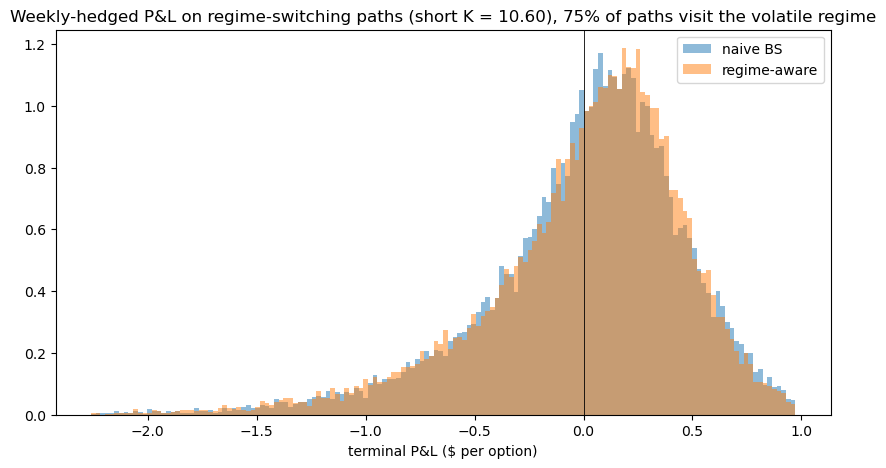

,hedger,mean,std,q05,std_visited,q05_visited
0,naive BS,0.0031,0.4796,-0.8759,0.4931,-0.9885
1,regime-aware,0.0038,0.4782,-0.8944,0.4942,-1.0109


In [7]:
N_HEDGE = 20_000
REBAL = 5    # weekly

Am, Bm, regm = simulate_regime_switching_gbm(A0, B0, rp, r_f, T, n_steps,
                                             N_HEDGE, rng)
detected = detect_regimes_from_paths(Am, dt, rp, window=21)

# true RS value of the K_ATM option (Margrabe CV on RS paths)
V0_rs, V0_se, _, _ = mc_spread_option_margrabe_cv(
    Ar[:, -1], Br[:, -1], K_ATM, r_f, T, V0_rs_K0)
print(f"RS premium V0(K_ATM) = {V0_rs:.4f} (SE {V0_se:.4f})")

# (a) naive constants: stationary variance/covariance mixing
s1_u = np.sqrt(rp["pi"] @ rp["sigma1"]**2)
s2_u = np.sqrt(rp["pi"] @ rp["sigma2"]**2)
rho_u = (rp["pi"] @ (rp["rho"] * rp["sigma1"] * rp["sigma2"])) / (s1_u * s2_u)
print(f"naive constants: sigma1 = {s1_u:.4f}, sigma2 = {s2_u:.4f}, "
      f"rho = {rho_u:.4f}")

# (b) regime-conditional expected parameters over the remaining life
s1_eff, s2_eff, rho_eff = expected_param_grids(rp, n_steps, T)

def naive_hedger(k, tau):
    prm = dict(sigma1=s1_u, sigma2=s2_u, rho=rho_u, r=r_f)
    return mc_deltas_fd_batch(Am[:, k], Bm[:, k], tau, K_ATM, prm,
                              M=4_000, seed=1000 + k)

def aware_hedger(k, tau):
    y = detected[:, k] if k > 0 else np.zeros(N_HEDGE, dtype=int)
    dA = np.empty(N_HEDGE)
    dB = np.empty(N_HEDGE)
    for state in (0, 1):
        m = y == state
        if not m.any():
            continue
        prm = dict(sigma1=s1_eff[state, k], sigma2=s2_eff[state, k],
                   rho=rho_eff[state, k], r=r_f)
        dA[m], dB[m] = mc_deltas_fd_batch(Am[m, k], Bm[m, k], tau, K_ATM,
                                          prm, M=4_000, seed=1000 + k)
    return dA, dB

visited = regm.max(axis=1) == 1
rows, pnls = [], {}
for name, fn in [("naive BS", naive_hedger),
                 ("regime-aware", aware_hedger)]:   # ~1 min each
    pnl = simulate_delta_hedge_rs(Am, Bm, K_ATM, r_f, T, V0_rs, REBAL, fn)
    pnls[name] = pnl
    rows.append((name, pnl.mean(), pnl.std(), np.quantile(pnl, 0.05),
                 pnl[visited].std(), np.quantile(pnl[visited], 0.05)))
race = pd.DataFrame(rows, columns=["hedger", "mean", "std", "q05",
                                   "std_visited", "q05_visited"]).round(4)

fig, ax = plt.subplots(figsize=(10, 5))
lo, hi = np.quantile(np.concatenate(list(pnls.values())), [0.002, 0.998])
for name, pnl in pnls.items():
    ax.hist(pnl, bins=150, range=(lo, hi), alpha=0.5, density=True, label=name)
ax.axvline(0, color="k", lw=0.6)
ax.set_xlabel("terminal P&L ($ per option)")
ax.legend()
ax.set_title(f"Weekly-hedged P&L on regime-switching paths "
             f"(short K = {K_ATM:.2f}), {visited.mean():.0%} of paths "
             "visit the volatile regime")
plt.show()

race

- **Pricing:** the RS-BS gap is small at every strike except deep
  OTM: $-0.027$ at $K_{\text{ATM}}$ ($-2.1\%$ of premium) but $+0.014$
  ($+32\%$) at $K = 16.84$, where the volatile regime's fat tail dominates a
  tiny BS price. Per-regime correlations are similar ($0.60$ vs $0.52$), so
  the mixture acts mostly through the vol level.
- **Hedging:** the regime-aware hedger is indistinguishable from
  naive — std $0.478$ vs $0.480$ overall, $0.494$ vs $0.493$ on the 
  volatile-visiting subset, q05 even slightly *worse* ($-1.01$ vs $-0.99$).
  The mechanism is measured in Sect. 5.2: the volatile regime lasts $15.3$ days
  on average vs a 21-day detection window, so detection arrives with roughly
  a full regime-lifetime of lag. A negative result with a measured mechanism
  — regime information matters for **pricing and risk measurement**
  (the $32\%$ tail mispricing), not for delta hedging.
- **Caveats:** weekly hedging (notebook 03's discretization error is in both
  hedgers and cancels in the comparison); regime labels inherit the
  rolling-window persistence bias (Sect. 5.2); detection is a threshold rule, not
  filtered probabilities (HMM/EM is the natural extension).